In [4]:
import re

def latex_table_to_matrix(latex_text):
    """
    Converte una tabella LaTeX in matrice numerica.

    Ritorna:
    - instances: lista nomi istanze
    - matrix: lista di liste di float
    """

    lines = latex_text.splitlines()

    data = []

    for line in lines:

        # Ignora comandi LaTeX
        if re.search(r"(\\hline|\\begin|\\end|\\multicolumn|\\caption|\\label|\\resizebox)", line):
            continue

        # Deve contenere dati
        if "&" not in line:
            continue

        # Rimuove fine riga
        line = line.replace("\\\\", "").strip()

        # Split colonne
        cols = [c.strip() for c in line.split("&")]

        # Nome istanza (prima colonna)
        instance = cols[0]

        # Salta righe non dati
        if not instance.startswith("instance"):
            continue

        # Rimuove colonne vuote
        values = cols[2:]

        row = []

        for v in values:

            # Rimuove %
            v = v.replace("%", "")

            # Rimuove spazi
            v = v.strip()

            # Converte in float
            try:
                num = float(v)
                row.append(num)
            except:
                pass

        if row:
            data.append((instance, row))

    instances = [d[0] for d in data]
    matrix = [d[1] for d in data]

    return instances, matrix


In [48]:
latex_text = r"""
\begin{table}[H]
\centering
\caption{results con funzione obbiettivo \eqref{Eq1.P1}}
\label{tab.new1}
\small
\resizebox{\textwidth}{!}{%
\begin{tabular}{|ll|rrr|rrr|rrr|} 
\hline
\multicolumn{2}{c|}{CPLEX} &     
\multicolumn{3}{c|}{Heuristic} &    
\multicolumn{3}{c|}{Lagrangian Heuristic}  \\  
\hline
Istanza                       &     &       Zopt &     Gap &     Time &      Zheu &      Time &    GHeu &      Zheu &      Time &    GHeu \\   
instance\_06\_01              &     &    44354.6 &    0.01 &     0.23 &    42288.7 &     0.03 &    4.66 &    42288.7 &     0.23 &     4.66  \\ 
instance\_06\_02              &     &    43181.6 &    0.01 &     0.42 &    41593.8 &     0.02 &    3.68 &    41593.8 &     0.22 &     3.68  \\ 
instance\_06\_03              &     &    41367.7 &    0.01 &     0.30 &    40156.1 &     0.02 &    2.93 &    40156.1 &     0.32 &     2.93  \\ 
instance\_06\_04              &     &    34073.1 &    0.01 &     0.11 &    27926.6 &     0.03 &   18.04 &    27926.6 &     0.33 &    18.04  \\ 
instance\_06\_05              &     &    34991.9 &    0.00 &     0.38 &    31021.3 &     0.03 &   11.35 &    31021.3 &     0.16 &    11.35  \\ 
instance\_20\_01              &     &   182020.7 &    1.02 &   300.10 &   178070.4 &     0.10 &    2.17 &   178070.4 &     3.01 &     2.17  \\ 
instance\_20\_02              &     &   203651.0 &    0.29 &   300.07 &   190858.2 &     0.12 &    6.28 &   190858.2 &     4.00 &     6.28  \\ 
instance\_20\_03              &     &   193769.0 &    0.01 &   217.66 &   177088.2 &     0.14 &    8.61 &   177088.2 &     3.03 &     8.61  \\ 
instance\_20\_04              &     &   173408.3 &    0.01 &   291.01 &   172678.6 &     0.14 &    0.42 &   172678.6 &     4.00 &     0.42  \\ 
instance\_20\_05              &     &   191724.4 &    3.38 &   300.05 &   170264.4 &     0.21 &   11.19 &   170264.4 &     2.46 &    11.19  \\ 
instance\_40\_01              &     &   821010.9 &    0.05 &   300.12 &   804849.4 &     0.18 &    1.97 &   804849.4 &    18.34 &     1.97  \\ 
instance\_40\_02              &     &   859090.7 &    0.08 &   300.12 &   826360.9 &     0.21 &    3.81 &   826360.9 &    14.45 &     3.81  \\ 
instance\_40\_03              &     &   822323.5 &    0.10 &   300.11 &   801463.7 &     0.15 &    2.54 &   801463.7 &    22.44 &     2.54  \\ 
instance\_40\_04              &     &   788923.6 &    0.48 &   300.13 &   773077.8 &     0.26 &    2.01 &   773077.8 &    27.66 &     2.01  \\ 
instance\_40\_05              &     &   789186.1 &    0.26 &   300.12 &   794218.8 &     0.20 &   -0.64 &   794218.8 &    23.21 &    -0.64  \\ 
instance\_100\_01             &     &  5492730.3 &    3.91 &   301.25 &  5638787.1 &     1.78 &   -2.66 &  5638787.1 &   300.18 &    -2.66  \\ 
instance\_100\_02             &     &  5361497.2 &    6.61 &   300.93 &  5647903.4 &     1.75 &   -5.34 &  5647903.4 &   300.13 &    -5.34  \\ 
instance\_100\_03             &     &  5613547.8 &    1.82 &   301.11 &  5631867.9 &     1.60 &   -0.33 &  5631867.9 &   300.72 &    -0.33  \\ 
instance\_100\_04             &     &  5725382.8 &    5.00 &   300.91 &  5890661.9 &     1.84 &   -2.89 &  5890661.9 &   300.26 &    -2.89  \\ 
instance\_100\_05             &     &  5430805.7 &    2.16 &   301.12 &  5530004.2 &     1.85 &   -1.83 &  5530004.2 &   300.02 &    -1.83  \\ 
instance\_f\_01              &     &   130009.8 &    0.00 &      0.22 &   120411.2 &     0.27 &    7.38 &   120411.2 &    23.69 &      7.38 \\ 
instance\_f\_02              &     &   134864.3 &    0.01 &     53.07 &   127857.5 &     0.31 &    5.20 &   127857.5 &    23.25 &      5.20 \\ 
instance\_f\_03              &     &   132266.3 &    0.00 &      0.77 &   124444.8 &     0.36 &    5.91 &   124444.8 &    14.66 &      5.91 \\ 
instance\_f\_04              &     &   130108.4 &    0.01 &     40.23 &   127565.4 &     0.27 &    1.96 &   127565.4 &    12.34 &      1.96 \\ 
instance\_f\_05              &     &   137811.6 &    0.01 &     19.82 &   121055.0 &     0.29 &   12.16 &   121055.0 &    17.91 &     12.16 \\
\hline
\end{tabular}
}
\end{table}
"""

instances, matrix = latex_table_to_matrix(latex_text)

print(instances)
print(matrix)
coll1 = [row[4] for row in matrix]

print(coll1)


['instance\\_06\\_01', 'instance\\_06\\_02', 'instance\\_06\\_03', 'instance\\_06\\_04', 'instance\\_06\\_05', 'instance\\_20\\_01', 'instance\\_20\\_02', 'instance\\_20\\_03', 'instance\\_20\\_04', 'instance\\_20\\_05', 'instance\\_40\\_01', 'instance\\_40\\_02', 'instance\\_40\\_03', 'instance\\_40\\_04', 'instance\\_40\\_05', 'instance\\_100\\_01', 'instance\\_100\\_02', 'instance\\_100\\_03', 'instance\\_100\\_04', 'instance\\_100\\_05', 'instance\\_f\\_01', 'instance\\_f\\_02', 'instance\\_f\\_03', 'instance\\_f\\_04', 'instance\\_f\\_05']
[[44354.6, 0.01, 0.23, 42288.7, 0.03, 4.66, 42288.7, 0.23, 4.66], [43181.6, 0.01, 0.42, 41593.8, 0.02, 3.68, 41593.8, 0.22, 3.68], [41367.7, 0.01, 0.3, 40156.1, 0.02, 2.93, 40156.1, 0.32, 2.93], [34073.1, 0.01, 0.11, 27926.6, 0.03, 18.04, 27926.6, 0.33, 18.04], [34991.9, 0.0, 0.38, 31021.3, 0.03, 11.35, 31021.3, 0.16, 11.35], [182020.7, 1.02, 300.1, 178070.4, 0.1, 2.17, 178070.4, 3.01, 2.17], [203651.0, 0.29, 300.07, 190858.2, 0.12, 6.28, 190858

In [45]:
latex_text = r"""
\begin{table}[H]
\centering
\caption{KPI con funzione obbiettivo \eqref{Eq2.P5}}
\label{tab.new007}
\small
\resizebox{\textwidth}{!}{%
\begin{tabular}{|ll|rrrrrr|rrrrrr|rrrrrr|} 
\hline

\multicolumn{2}{c|}{   } & 
\multicolumn{6}{c|}{CPLEX} &     
\multicolumn{6}{c|}{Heuristic} &    
\multicolumn{6}{c|}{Lagrangian Heuristic} \\  
Istanza  &   &                         D.R. &  R.MAX &  R.MIN &  D.U.   &  U.MAX  & U.MIN &  D.R. &  R.MAX &  R.MIN &  D.U.   &  U.MAX  & U.MIN &  D.R. &  R.MAX &  R.MIN &  D.U.   &  U.MAX  & U.MIN  \\
instance\_06\_01              &     &   3.6  &   10.6  &  1.3  &   3.3  &   10.1  &  1.3  &    3.1  &   11.3  &  3.4  &   2.9  &   10.7  &  3.2  &     3.1  &   11.3  &  3.4  &   2.9  &   10.7  &  3.2   \\    
instance\_06\_02              &     &   2.3  &   7.5  &  1.1  &   2.0  &   8.0  &  2.0  &      2.5  &   10.2  &  1.9  &   2.4  &   9.7  &  1.5  &      2.5  &   10.2  &  1.9  &   2.4  &   9.7  &  1.5   \\    
instance\_06\_03              &     &   1.8  &   8.6  &  3.4  &   2.2  &   9.7  &  3.5  &      3.2  &   10.6  &  1.5  &   3.6  &   12.7  &  1.8  &     3.2  &   10.6  &  1.5  &   3.6  &   12.7  &  1.8   \\    
instance\_06\_04              &     &   2.6  &   10.1  &  2.9  &   2.2  &   10.5  &  3.8  &    2.7  &   10.2  &  2.9  &   2.4  &   10.5  &  3.8  &     2.7  &   10.2  &  2.9  &   2.4  &   10.5  &  3.8   \\     
instance\_06\_05              &     &   3.0  &   9.9  &  1.8  &   2.9  &   9.3  &  1.5  &     1.7  &   9.9  &  4.5  &   1.4  &   9.2  &  5.0  &        1.7  &   9.9  &  4.5  &   1.4  &   9.2  &  5.0   \\
instance\_20\_01              &     &    1.3  &   7.0  &  2.5  &   0.9  &   5.7  &  2.6  &      1.4  &   6.8  &  2.0  &   0.9  &   5.4  &  1.9  &       1.4  &   6.8  &  2.0  &   0.9  &   5.4  &  1.9   \\ 
instance\_20\_02              &     &    1.4  &   7.9  &  1.3  &   1.1  &   5.8  &  1.8  &      1.7  &   8.0  &  1.7  &   1.3  &   5.8  &  1.9  &       1.7  &   8.0  &  1.7  &   1.3  &   5.8  &  1.9   \\ 
instance\_20\_03              &     &    1.4  &   6.6  &  1.3  &   0.9  &   5.8  &  2.0  &      1.4  &   7.5  &  1.3  &   1.1  &   6.1  &  2.0  &       1.4  &   7.5  &  1.3  &   1.1  &   6.1  &  2.0   \\
instance\_20\_04              &     &    1.3  &   7.3  &  1.9  &   1.1  &   7.0  &  2.0  &      1.2  &   6.3  &  1.7  &   0.8  &   5.9  &  2.0  &       1.2  &   6.3  &  1.7  &   0.8  &   5.9  &  2.0   \\   
instance\_20\_05              &     &    1.3  &   7.0  &  2.4  &   1.0  &   6.0  &  2.6  &      1.5  &   8.1  &  2.2  &   1.1  &   6.9  &  2.6  &       1.5  &   8.1  &  2.2  &   1.1  &   6.9  &  2.6   \\ 
instance\_40\_01              &     &    3.1  &   15.4  &  1.3  &   2.4  &   13.7  &  1.9  &    3.4  &   15.5  &  1.5  &   2.3  &   11.8  &  1.9  &     3.4  &   15.5  &  1.5  &   2.3  &   11.8  &  1.9   \\          
instance\_40\_02              &     &    3.1  &   15.3  &  3.1  &   2.5  &   15.2  &  3.6  &    3.7  &   15.6  &  1.4  &   2.9  &   14.5  &  1.9  &     3.7  &   15.6  &  1.4  &   2.9  &   14.5  &  1.9   \\           
instance\_40\_03              &     &    2.5  &   16.4  &  5.2  &   1.9  &   15.1  &  6.9  &    3.1  &   16.0  &  4.3  &   2.1  &   13.7  &  5.1  &     3.1  &   16.0  &  4.3  &   2.1  &   13.7  &  5.1   \\           
instance\_40\_04              &     &   2.4  &   13.1  &  3.0  &   2.1  &   12.5  &  4.0  &     2.2  &   12.4  &  4.3  &   2.0  &   12.9  &  5.7  &     2.2  &   12.4  &  4.3  &   2.0  &   12.9  &  5.7   \\            
instance\_40\_05              &     &    2.6  &   14.8  &  3.8  &   1.9  &   12.4  &  5.5  &    3.1  &   15.2  &  3.9  &   2.2  &   13.1  &  5.8  &     3.1  &   15.2  &  3.9  &   2.2  &   13.1  &  5.8   \\           
instance\_100\_01             &     &     1.5  &   8.1  &  1.6  &   1.1  &   7.2  &  1.5  &     1.7  &   9.6  &  1.1  &   1.2  &   7.6  &  2.0  &       1.7  &   9.6  &  1.1  &   1.2  &   7.6  &  2.0   \\           
instance\_100\_02             &     &    1.7  &   9.6  &  1.1  &   1.2  &   7.6  &  2.0  &      1.8  &   11.2  &  2.1  &   1.3  &   8.5  &  2.7  &      1.8  &   11.2  &  2.1  &   1.3  &   8.5  &  2.7   \\           
instance\_100\_03             &     &    1.5  &   11.9  &  1.4  &   1.1  &   7.9  &  1.8  &     1.6  &   11.4  &  2.5  &   1.1  &   8.3  &  2.8  &      1.6  &   11.4  &  2.5  &   1.1  &   8.3  &  2.8   \\           
instance\_100\_04             &     &    1.6  &   10.5  &  1.5  &   1.1  &   6.8  &  1.8  &     1.7  &   10.6  &  1.1  &   1.2  &   7.6  &  2.0  &      1.7  &   10.6  &  1.1  &   1.2  &   7.6  &  2.0   \\           
instance\_100\_05             &     &    1.4  &   8.6  &  1.4  &   1.2  &   7.9  &  1.9  &      1.7  &   9.4  &  1.9  &   1.3  &   7.8  &  2.0  &       1.7  &   9.4  &  1.9  &   1.3  &   7.8  &  2.0   \\    
instance\_f\_01               &     &   5.5  &   19.0  &  1.7  &   5.2  &   18.1  &  2.0  &    5.1  &   18.3  &  2.9  &   4.3  &   16.8  &  3.9  &     5.1  &   18.3  &  2.9  &   4.3  &   16.8  &  3.9   \\   
instance\_f\_02               &     &    4.3  &   17.5  &  5.3  &   2.8  &   14.4  &  5.7  &    5.5  &   21.1  &  2.8  &   4.0  &   18.1  &  3.8  &     5.5  &   21.1  &  2.8  &   4.0  &   18.1  &  3.8   \\         
instance\_f\_03               &     &   3.0  &   14.7  &  5.8  &   2.4  &   14.3  &  6.5  &    3.6  &   14.7  &  3.1  &   3.5  &   16.3  &  3.8  &     3.6  &   14.7  &  3.1  &   3.5  &   16.3  &  3.8   \\    
instance\_f\_04               &     &    5.1  &   21.5  &  2.7  &   4.7  &   21.0  &  3.7  &    6.7  &   26.1  &  2.5  &   5.9  &   23.9  &  3.7  &     6.7  &   26.1  &  2.5  &   5.9  &   23.9  &  3.7   \\        
instance\_f\_05               &     &   4.6  &   19.7  &  4.8  &   3.6  &   17.4  &  4.8  &    4.0  &   18.8  &  6.4  &   3.5  &   17.7  &  6.4  &     4.0  &   18.8  &  6.4  &   3.5  &   17.7  &  6.4   \\   
 \hline
\end{tabular}
}
\end{table}
"""

instances2, matrix2 = latex_table_to_matrix(latex_text)

print(instances2)
print(matrix2)


['instance\\_06\\_01', 'instance\\_06\\_02', 'instance\\_06\\_03', 'instance\\_06\\_04', 'instance\\_06\\_05', 'instance\\_20\\_01', 'instance\\_20\\_02', 'instance\\_20\\_03', 'instance\\_20\\_04', 'instance\\_20\\_05', 'instance\\_40\\_01', 'instance\\_40\\_02', 'instance\\_40\\_03', 'instance\\_40\\_04', 'instance\\_40\\_05', 'instance\\_100\\_01', 'instance\\_100\\_02', 'instance\\_100\\_03', 'instance\\_100\\_04', 'instance\\_100\\_05', 'instance\\_f\\_01', 'instance\\_f\\_02', 'instance\\_f\\_03', 'instance\\_f\\_04', 'instance\\_f\\_05']
[[3.6, 10.6, 1.3, 3.3, 10.1, 1.3, 3.1, 11.3, 3.4, 2.9, 10.7, 3.2, 3.1, 11.3, 3.4, 2.9, 10.7, 3.2], [2.3, 7.5, 1.1, 2.0, 8.0, 2.0, 2.5, 10.2, 1.9, 2.4, 9.7, 1.5, 2.5, 10.2, 1.9, 2.4, 9.7, 1.5], [1.8, 8.6, 3.4, 2.2, 9.7, 3.5, 3.2, 10.6, 1.5, 3.6, 12.7, 1.8, 3.2, 10.6, 1.5, 3.6, 12.7, 1.8], [2.6, 10.1, 2.9, 2.2, 10.5, 3.8, 2.7, 10.2, 2.9, 2.4, 10.5, 3.8, 2.7, 10.2, 2.9, 2.4, 10.5, 3.8], [3.0, 9.9, 1.8, 2.9, 9.3, 1.5, 1.7, 9.9, 4.5, 1.4, 9.2, 5.0, 1

In [23]:
import numpy as np


def compare_matrices_columns(M1, M2, tol=1e-9):

    A = np.array(M1, dtype=float)
    B = np.array(M2, dtype=float)

    if A.shape != B.shape:
        raise ValueError("Le matrici devono avere la stessa dimensione")

    n_rows, n_cols = A.shape

    results = {}

    for j in range(n_cols):

        colA = A[:, j]
        colB = B[:, j]

        diff = colA - colB
        abs_diff = np.abs(diff)

        meanA = colA.mean()

        mean_diff = diff.mean()
        mean_abs_diff = abs_diff.mean()

        # Proporzioni (normalizzate)
        if abs(meanA) > tol:
            mean_diff_prop = mean_diff / meanA
            mean_abs_diff_prop = mean_abs_diff / meanA
        else:
            mean_diff_prop = None
            mean_abs_diff_prop = None

        results[f"col_{j}"] = {
            # Valori assoluti
            "mean_diff": float(mean_diff),
            "mean_abs_diff": float(mean_abs_diff),

            # Valori proporzionali
            "mean_diff_prop": None if mean_diff_prop is None else float(mean_diff_prop),
            "mean_abs_diff_prop": None if mean_abs_diff_prop is None else float(mean_abs_diff_prop),

            # Altre statistiche
            "max_diff": float(diff.max()),
            "min_diff": float(diff.min()),
            "A_better": int((colA > colB + tol).sum()),
            "B_better": int((colB > colA + tol).sum()),
            "equal": int((np.abs(diff) <= tol).sum())
        }

    return results


In [46]:
res = compare_matrices_columns(matrix, matrix2)

for col, stats in res.items():
    print(col, stats)


col_0 {'mean_diff': 0.7120000000000001, 'mean_abs_diff': 0.9039999999999999, 'mean_diff_prop': 0.21787025703794372, 'mean_abs_diff_prop': 0.2766217870257037, 'max_diff': 6.0, 'min_diff': -1.0, 'A_better': 15, 'B_better': 8, 'equal': 2}
col_1 {'mean_diff': 2.536, 'mean_abs_diff': 3.176, 'mean_diff_prop': 0.17513812154696132, 'mean_abs_diff_prop': 0.21933701657458565, 'max_diff': 18.000000000000004, 'min_diff': -3.3000000000000007, 'A_better': 18, 'B_better': 7, 'equal': 0}
col_2 {'mean_diff': -0.18799999999999997, 'mean_abs_diff': 1.1, 'mean_diff_prop': -0.0797962648556876, 'mean_abs_diff_prop': 0.46689303904923607, 'max_diff': 3.0, 'min_diff': -3.1999999999999997, 'A_better': 11, 'B_better': 13, 'equal': 1}
col_3 {'mean_diff': 1.068, 'mean_abs_diff': 1.14, 'mean_diff_prop': 0.33584905660377357, 'mean_abs_diff_prop': 0.3584905660377358, 'max_diff': 5.799999999999999, 'min_diff': -0.8999999999999999, 'A_better': 21, 'B_better': 1, 'equal': 3}
col_4 {'mean_diff': 3.488, 'mean_abs_diff': 3

In [33]:
import numpy as np


def column_percentage_difference(M, c1, c2, tol=1e-9):
    """
    Calcola la differenza percentuale tra due colonne di una matrice.

    (colonna c1 vs colonna c2)

    Formula:
    (c1 - c2) / c2 * 100

    Parametri:
    - M: matrice (lista di liste o numpy array)
    - c1: indice prima colonna
    - c2: indice seconda colonna

    Ritorna:
    array numpy con percentuali per ogni riga
    """

    A = np.array(M, dtype=float)

    if c1 >= A.shape[1] or c2 >= A.shape[1]:
        raise ValueError("Indice colonna fuori range")

    col1 = A[:, c1]
    col2 = A[:, c2]

    result = np.zeros(len(col1))


    for i in range(len(col1)):
        result[i] = (col1[i]-col2[i])/((col1[i]+col2[i])/2) # divisione per zero

    return result.mean()


In [40]:
diff = column_percentage_difference(matrix, 1, 4)

print(diff)

0.1117317647865193


In [51]:
latex_text = r"""
\begin{table}[H]
\centering
\caption{confronto tempi di esecuzione tra le due funzioni obbiettivo \eqref{Eq1.P1} e \eqref{Eq2.P1}}
\label{tab.new3}
\small
\resizebox{\textwidth}{!}{%
\begin{tabular}{|ll|rrr|rrr|} 
\hline
\multicolumn{2}{c|}{   } &
\multicolumn{3}{c|}{Funzioni obbiettivo\eqref{Eq1.P1}} &     
\multicolumn{3}{c|}{Funzioni obbiettivo\eqref{Eq2.P1}}  \\  
\hline
Istanza                       &     &      CPLEX Time &  Heuristic Time &    Lagrangian Heuristic Time &      CPLEX Time &  Heuristic Time &    Lagrangian Heuristic Time  \\   
instance\_06\_01              &     &      0.23 &   0.03 &      0.23 &      0.13 &     0.02 &      0.16 \\ 
instance\_06\_02              &     &      0.42 &   0.02 &      0.22 &      0.43 &     0.02 &      0.38 \\ 
instance\_06\_03              &     &      0.30 &   0.02 &      0.32 &      0.26 &     0.02 &      0.28 \\ 
instance\_06\_04              &     &      0.11 &   0.03 &      0.33 &      0.06 &     0.03 &      0.22 \\ 
instance\_06\_05              &     &      0.38 &   0.03 &      0.16 &      0.30 &     0.02 &      0.14 \\ 
instance\_20\_01              &     &    300.10 &   0.10 &      3.01 &    300.09 &     0.09 &      2.10 \\ 
instance\_20\_02              &     &    300.07 &   0.12 &      4.00 &    300.11 &     0.10 &      3.34 \\ 
instance\_20\_03              &     &    217.66 &   0.14 &      3.03 &    200.22 &     0.13 &      2.40 \\ 
instance\_20\_04              &     &    291.01 &   0.14 &      4.00 &     88.79 &     0.12 &      2.63 \\ 
instance\_20\_05              &     &    300.05 &   0.21 &      2.46 &    300.12 &     0.13 &      2.82 \\ 
instance\_40\_01              &     &    300.12 &   0.18 &     18.34 &    300.10 &     0.15 &     20.06 \\ 
instance\_40\_02              &     &    300.12 &   0.21 &     14.45 &    300.10 &     0.18 &     15.56 \\ 
instance\_40\_03              &     &    300.11 &   0.15 &     22.44 &    300.10 &     0.23 &     21.00 \\ 
instance\_40\_04              &     &    300.13 &   0.26 &     27.66 &    300.12 &     0.16 &     26.84 \\ 
instance\_40\_05              &     &    300.12 &   0.20 &     23.21 &    300.14 &     0.14 &     23.19 \\ 
instance\_100\_01             &     &    301.25 &   1.78 &    300.18 &    301.18 &     1.68 &    300.44 \\ 
instance\_100\_02             &     &    300.93 &   1.75 &    300.13 &    300.92 &     1.48 &    300.73 \\ 
instance\_100\_03             &     &    301.11 &   1.60 &    300.72 &    301.07 &     1.34 &    300.73 \\ 
instance\_100\_04             &     &    300.91 &   1.84 &    300.26 &    302.31 &     1.65 &    300.26 \\ 
instance\_100\_05             &     &    301.12 &   1.85 &    300.02 &    301.10 &     1.53 &    300.34 \\ 
instance\_f\_01                &     &    0.22 &     0.27 &    23.69  &      6.08 &     0.28 &    25.06  \\  
instance\_f\_02                &     &   53.07 &     0.31 &    23.25   &     76.14 &     0.26 &    21.04  \\  
instance\_f\_03                &     &    0.77 &     0.36 &    14.66   &     73.87 &     0.25 &    13.35  \\  
instance\_f\_04                &     &   40.23 &     0.27 &    12.34   &     61.72 &     0.26 &    11.22  \\  
instance\_f\_05                &     &   19.82 &     0.29 &    17.91   &     25.08 &     0.29 &    17.36  \\  
\hline
\end{tabular}
}
\end{table}
"""

instances, matrix = latex_table_to_matrix(latex_text)

print(instances)
print(matrix)
coll1 = [row[1] for row in matrix]

print(coll1)
coll2 = [row[4] for row in matrix]

print(coll2)


['instance\\_06\\_01', 'instance\\_06\\_02', 'instance\\_06\\_03', 'instance\\_06\\_04', 'instance\\_06\\_05', 'instance\\_20\\_01', 'instance\\_20\\_02', 'instance\\_20\\_03', 'instance\\_20\\_04', 'instance\\_20\\_05', 'instance\\_40\\_01', 'instance\\_40\\_02', 'instance\\_40\\_03', 'instance\\_40\\_04', 'instance\\_40\\_05', 'instance\\_100\\_01', 'instance\\_100\\_02', 'instance\\_100\\_03', 'instance\\_100\\_04', 'instance\\_100\\_05', 'instance\\_f\\_01', 'instance\\_f\\_02', 'instance\\_f\\_03', 'instance\\_f\\_04', 'instance\\_f\\_05']
[[0.23, 0.03, 0.23, 0.13, 0.02, 0.16], [0.42, 0.02, 0.22, 0.43, 0.02, 0.38], [0.3, 0.02, 0.32, 0.26, 0.02, 0.28], [0.11, 0.03, 0.33, 0.06, 0.03, 0.22], [0.38, 0.03, 0.16, 0.3, 0.02, 0.14], [300.1, 0.1, 3.01, 300.09, 0.09, 2.1], [300.07, 0.12, 4.0, 300.11, 0.1, 3.34], [217.66, 0.14, 3.03, 200.22, 0.13, 2.4], [291.01, 0.14, 4.0, 88.79, 0.12, 2.63], [300.05, 0.21, 2.46, 300.12, 0.13, 2.82], [300.12, 0.18, 18.34, 300.1, 0.15, 20.06], [300.12, 0.21, 

In [52]:
latex_text = r"""
\begin{table}[H]
\centering
\caption{confronto tempi di esecuzione tra le due funzioni obbiettivo \eqref{Eq2.P2} e \eqref{Eq2.P3}}
\label{tab.new4}
\small
\resizebox{\textwidth}{!}{%
\begin{tabular}{|ll|rrr|rrr|} 
\hline
\multicolumn{2}{c|}{   } &
\multicolumn{3}{c|}{Funzioni obbiettivo\eqref{Eq2.P2}} &     
\multicolumn{3}{c|}{Funzioni obbiettivo\eqref{Eq2.P3}}  \\  
\hline
Istanza                       &     &      CPLEX Time &  Heuristic Time &    Lagrangian Heuristic Time &      CPLEX Time &  Heuristic Time &    Lagrangian Heuristic Time  \\   
instance\_06\_01             &     &    0.12 &     0.02 &     0.14 &    0.03 &     0.02 &     0.16 \\ 
instance\_06\_02             &     &    0.39 &     0.02 &     0.24 &    0.26 &     0.02 &     0.34 \\ 
instance\_06\_03             &     &    0.36 &     0.02 &     0.41 &    0.46 &     0.03 &     0.41 \\ 
instance\_06\_04             &     &    0.09 &     0.04 &     0.27 &    0.03 &     0.02 &     0.27 \\ 
instance\_06\_05             &     &    0.24 &     0.02 &     0.15 &    0.42 &     0.02 &     0.15 \\ 
instance\_20\_01             &     &  300.09 &     0.09 &     2.11 &  300.07 &     0.09 &     2.52 \\ 
instance\_20\_02             &     &  300.10 &     0.13 &     3.37 &  128.92 &     0.10 &     3.57 \\ 
instance\_20\_03             &     &  300.10 &     0.15 &     2.39 &  271.07 &     0.13 &     2.37 \\ 
instance\_20\_04             &     &  232.82 &     0.13 &     2.59 &  287.18 &     0.10 &     2.67 \\ 
instance\_20\_05             &     &  300.11 &     0.15 &     2.27 &  300.05 &     0.12 &     2.00 \\ 
instance\_40\_01             &     &  300.13 &     0.23 &    16.53 &  300.12 &     0.27 &    17.70 \\ 
instance\_40\_02             &     &  300.12 &     0.15 &    14.26 &  300.10 &     0.16 &    16.10 \\ 
instance\_40\_03             &     &  300.09 &     0.28 &    19.72 &  300.10 &     0.15 &    17.05 \\ 
instance\_40\_04             &     &  300.11 &     0.21 &    24.39 &  300.16 &     0.15 &    23.99 \\ 
instance\_40\_05             &     &  300.12 &     0.21 &    22.86 &  300.12 &     0.19 &    25.55 \\ 
instance\_100\_01            &     &  301.24 &     1.72 &   300.47 &  301.20 &     1.61 &   300.01 \\ 
instance\_100\_02            &     &  300.98 &     1.66 &   300.42 &  300.94 &     1.52 &   300.01 \\ 
instance\_100\_03            &     &  301.12 &     1.43 &   300.71 &  301.10 &     1.46 &   300.60 \\ 
instance\_100\_04            &     &  300.97 &     1.81 &   300.19 &  300.94 &     1.91 &   300.60 \\ 
instance\_100\_05            &     &  301.10 &     1.64 &   300.52 &  301.10 &     1.59 &   300.27 \\ 
instance\_f\_01              &     &     4.45 &    0.27 &    22.54 &   24.06 &     0.28 &    24.49   \\  
instance\_f\_02              &     &   177.38 &    0.31 &    21.26 &   223.67 &     0.27 &    24.92  \\  
instance\_f\_03              &     &     1.68 &    0.28 &    13.01 &     1.01 &     0.25 &    13.77  \\  
instance\_f\_04              &     &    75.31 &    0.39 &    12.89 &     0.84 &     0.29 &    12.01  \\  
instance\_f\_05              &     &    26.09 &    0.32 &    17.52 &    14.03 &     0.26 &    17.30  \\  
 
\hline
\end{tabular}
}
\end{table}
"""

instances, matrix = latex_table_to_matrix(latex_text)

print(instances)
print(matrix)
coll3 = [row[1] for row in matrix]

print(coll3)
coll4 = [row[4] for row in matrix]

print(coll4)

['instance\\_06\\_01', 'instance\\_06\\_02', 'instance\\_06\\_03', 'instance\\_06\\_04', 'instance\\_06\\_05', 'instance\\_20\\_01', 'instance\\_20\\_02', 'instance\\_20\\_03', 'instance\\_20\\_04', 'instance\\_20\\_05', 'instance\\_40\\_01', 'instance\\_40\\_02', 'instance\\_40\\_03', 'instance\\_40\\_04', 'instance\\_40\\_05', 'instance\\_100\\_01', 'instance\\_100\\_02', 'instance\\_100\\_03', 'instance\\_100\\_04', 'instance\\_100\\_05', 'instance\\_f\\_01', 'instance\\_f\\_02', 'instance\\_f\\_03', 'instance\\_f\\_04', 'instance\\_f\\_05']
[[0.12, 0.02, 0.14, 0.03, 0.02, 0.16], [0.39, 0.02, 0.24, 0.26, 0.02, 0.34], [0.36, 0.02, 0.41, 0.46, 0.03, 0.41], [0.09, 0.04, 0.27, 0.03, 0.02, 0.27], [0.24, 0.02, 0.15, 0.42, 0.02, 0.15], [300.09, 0.09, 2.11, 300.07, 0.09, 2.52], [300.1, 0.13, 3.37, 128.92, 0.1, 3.57], [300.1, 0.15, 2.39, 271.07, 0.13, 2.37], [232.82, 0.13, 2.59, 287.18, 0.1, 2.67], [300.11, 0.15, 2.27, 300.05, 0.12, 2.0], [300.13, 0.23, 16.53, 300.12, 0.27, 17.7], [300.12, 0

In [53]:
latex_text = r"""
\begin{table}[H]
\centering
\caption{confronto tempi di esecuzione tra le due funzioni obbiettivo \eqref{Eq2.P4} e \eqref{Eq2.P5}}
\label{tab.new6}
\small
\resizebox{\textwidth}{!}{%
\begin{tabular}{|ll|rrr|rrr|} 
\hline
\multicolumn{2}{c|}{   } &
\multicolumn{3}{c|}{Funzioni obbiettivo\eqref{Eq2.P4}} &     
\multicolumn{3}{c|}{Funzioni obbiettivo\eqref{Eq2.P5}}  \\  
\hline
Istanza                       &     &      CPLEX Time &  Heuristic Time &    Lagrangian Heuristic Time &      CPLEX Time &  Heuristic Time &    Lagrangian Heuristic Time  \\   
instance\_06\_01             &     &     0.05 &      0.02 &       0.14   &    0.06 &     0.03 &     0.26 \\   
instance\_06\_02             &     &     0.72 &      0.03 &       0.23   &    0.39 &     0.03 &     0.42 \\   
instance\_06\_03             &     &     0.25 &      0.02 &       0.39   &    0.35 &     0.04 &     0.42 \\   
instance\_06\_04             &     &     0.06 &      0.02 &       0.28   &    0.04 &     0.03 &     0.50 \\   
instance\_06\_05             &     &     0.30 &      0.02 &       0.14   &    0.37 &     0.10 &     0.27 \\   
instance\_20\_01             &     &   300.05 &      0.12 &       2.14   &  300.04 &     0.08 &     2.43 \\   
instance\_20\_02             &     &   300.07 &      0.11 &       3.39   &  300.17 &     0.11 &     2.03 \\   
instance\_20\_03             &     &   300.16 &      0.18 &       2.41   &  300.07 &     0.10 &     1.99 \\   
instance\_20\_04             &     &   300.07 &      0.12 &       2.37   &  300.06 &     0.09 &     2.20 \\   
instance\_20\_05             &     &   300.10 &      0.15 &       2.43   &  300.05 &     0.09 &     2.76 \\   
instance\_40\_01             &     &   300.09 &      0.22 &      20.01   &  300.11 &     0.16 &     7.52 \\   
instance\_40\_02             &     &   300.12 &      0.21 &      18.55   &  300.11 &     0.11 &     9.22 \\   
instance\_40\_03             &     &   300.11 &      0.27 &      17.10   &  300.11 &     0.15 &    10.44 \\   
instance\_40\_04             &     &   300.10 &      0.20 &      24.32   &  300.11 &     0.13 &     9.71 \\   
instance\_40\_05             &     &   300.34 &      0.21 &      31.59   &  300.23 &     0.14 &     7.29 \\   
instance\_100\_01            &     &   301.17 &      2.12 &     300.30   &  301.20 &     1.43 &   156.91 \\   
instance\_100\_02            &     &   300.92 &      1.87 &     300.49   &  300.96 &     1.40 &   199.44 \\   
instance\_100\_03            &     &   301.06 &      3.50 &     300.45   &  301.12 &     2.97 &   244.32 \\   
instance\_100\_04            &     &   300.99 &      3.79 &     300.21   &  300.93 &     1.78 &   231.82 \\   
instance\_100\_05            &     &   301.83 &      2.62 &    300.30 &   301.90 &     1.48 &   274.63 \\ 
instance\_f\_01              &     &   300.63 &      0.31 &    25.16 &   39.65 &     0.76 &   23.86 \\  
instance\_f\_02              &     &   300.44 &      0.40 &    22.89 &    69.11 &     0.29 &   22.24 \\  
instance\_f\_03              &     &   300.58 &      0.63 &    14.82 &    15.99 &     0.44 &   14.67 \\  
instance\_f\_04              &     &   300.48 &      0.66 &    12.78 &   135.48 &     0.63 &   10.77 \\  
instance\_f\_05              &     &   300.55 &      0.77 &    18.89 &     4.86 &     0.54 &   18.46 \\ 

\hline
\end{tabular}
}
\end{table}
"""

instances, matrix = latex_table_to_matrix(latex_text)

print(instances)
print(matrix)
coll5 = [row[1] for row in matrix]

print(coll5)
coll6 = [row[4] for row in matrix]

print(coll6)

['instance\\_06\\_01', 'instance\\_06\\_02', 'instance\\_06\\_03', 'instance\\_06\\_04', 'instance\\_06\\_05', 'instance\\_20\\_01', 'instance\\_20\\_02', 'instance\\_20\\_03', 'instance\\_20\\_04', 'instance\\_20\\_05', 'instance\\_40\\_01', 'instance\\_40\\_02', 'instance\\_40\\_03', 'instance\\_40\\_04', 'instance\\_40\\_05', 'instance\\_100\\_01', 'instance\\_100\\_02', 'instance\\_100\\_03', 'instance\\_100\\_04', 'instance\\_100\\_05', 'instance\\_f\\_01', 'instance\\_f\\_02', 'instance\\_f\\_03', 'instance\\_f\\_04', 'instance\\_f\\_05']
[[0.05, 0.02, 0.14, 0.06, 0.03, 0.26], [0.72, 0.03, 0.23, 0.39, 0.03, 0.42], [0.25, 0.02, 0.39, 0.35, 0.04, 0.42], [0.06, 0.02, 0.28, 0.04, 0.03, 0.5], [0.3, 0.02, 0.14, 0.37, 0.1, 0.27], [300.05, 0.12, 2.14, 300.04, 0.08, 2.43], [300.07, 0.11, 3.39, 300.17, 0.11, 2.03], [300.16, 0.18, 2.41, 300.07, 0.1, 1.99], [300.07, 0.12, 2.37, 300.06, 0.09, 2.2], [300.1, 0.15, 2.43, 300.05, 0.09, 2.76], [300.09, 0.22, 20.01, 300.11, 0.16, 7.52], [300.12, 0.

In [ ]:
!pip install matplotlib
import matplotlib.pyplot as plt

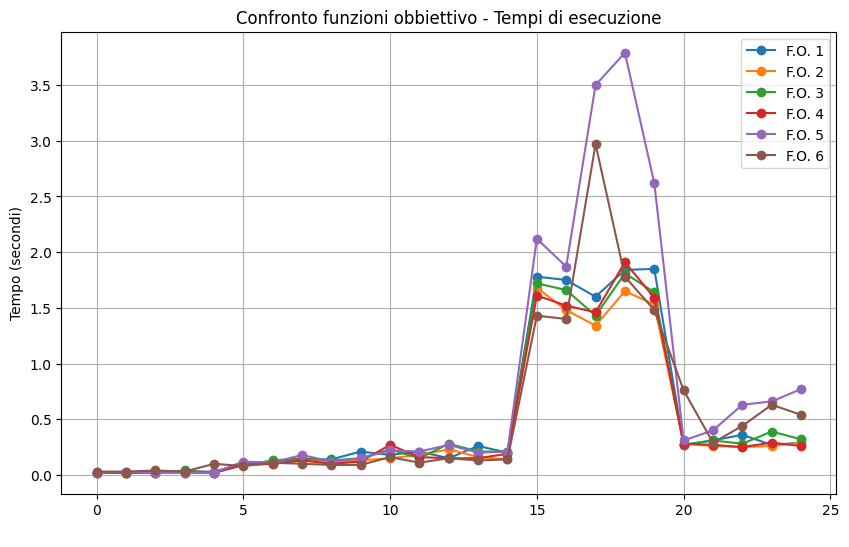

In [59]:


# I tuoi 6 array
A1 = [0.02, 0.03, 0.02, 0.02, 0.02, 0.12, 0.11, 0.18, 0.12, 0.15, 0.22, 0.21, 0.27, 0.2, 0.21, 2.12, 1.87, 3.5, 3.79, 2.62, 0.31, 0.4, 0.63, 0.66, 0.77]
A2 = [0.03, 0.03, 0.04, 0.03, 0.1, 0.08, 0.11, 0.1, 0.09, 0.09, 0.16, 0.11, 0.15, 0.13, 0.14, 1.43, 1.4, 2.97, 1.78, 1.48, 0.76, 0.29, 0.44, 0.63, 0.54]
A3 = [0.02, 0.02, 0.02, 0.04, 0.02, 0.09, 0.13, 0.15, 0.13, 0.15, 0.23, 0.15, 0.28, 0.21, 0.21, 1.72, 1.66, 1.43, 1.81, 1.64, 0.27, 0.31, 0.28, 0.39, 0.32]
A4 = [0.02, 0.02, 0.03, 0.02, 0.02, 0.09, 0.1, 0.13, 0.1, 0.12, 0.27, 0.16, 0.15, 0.15, 0.19, 1.61, 1.52, 1.46, 1.91, 1.59, 0.28, 0.27, 0.25, 0.29, 0.26]
A5 = [0.03, 0.02, 0.02, 0.03, 0.03, 0.1, 0.12, 0.14, 0.14, 0.21, 0.18, 0.21, 0.15, 0.26, 0.2, 1.78, 1.75, 1.6, 1.84, 1.85, 0.27, 0.31, 0.36, 0.27, 0.29]
A6 = [0.02, 0.02, 0.02, 0.03, 0.02, 0.09, 0.1, 0.13, 0.12, 0.13, 0.15, 0.18, 0.23, 0.16, 0.14, 1.68, 1.48, 1.34, 1.65, 1.53, 0.28, 0.26, 0.25, 0.26, 0.29]

# Lista di array per iterare
arrays = [coll1, coll2, coll3, coll4, coll5, coll6]

plt.figure(figsize=(10,6))

for i, arr in enumerate(arrays):
    plt.plot(arr, marker='o', label=f'F.O. {i+1}')  # aggiunta legenda

plt.xlabel(" ")  # X senza indicazione
plt.ylabel("Tempo (secondi)")
plt.title("Confronto funzioni obbiettivo - Tempi di esecuzione")
plt.grid(True)
plt.legend()  # mostra la legenda
plt.show()


In [60]:
latex_text = r"""
\begin{table}[H]
\centering
\caption{KPI con funzione obbiettivo \eqref{Eq1.P1}}
\label{tab.new2}
\small
\resizebox{\textwidth}{!}{%
\begin{tabular}{|ll|rrr|rrr|rrr|} 
\hline

\multicolumn{2}{c|}{   } & 
\multicolumn{3}{c|}{CPLEX} &     
\multicolumn{3}{c|}{Heuristic} &    
\multicolumn{3}{c|}{Lagrangian Heuristic} \\  
Istanza  &   &                        N.U.S. &  A.S.U.   &  H.U.S. & N.U.S. &  A.S.U.  &  H.U.S. & N.U.S. &  A.S.U.   &  H.U.S.\\
instance\_06\_01              &     &   5    &  95.59\%  &   2    &   5   &    95.38  &   2   &   5   &   95.38\%  &   2  \\  
instance\_06\_02              &     &   7    &  84.68\%  &   2    &   7   &    84.20  &   2   &   7   &   84.20\%  &   2  \\   
instance\_06\_03              &     &   6    &  88.89\%  &   2    &   6   &    90.71  &   2   &   6   &   90.71\%  &   2  \\   
instance\_06\_04              &     &   5    &  86.65\%  &   2    &   5   &    86.10  &   2   &   5   &   86.10\%  &   2  \\   
instance\_06\_05              &     &   5    &  98.34\%  &   2    &   6   &    81.43  &   2   &   6   &   81.43\%  &   2  \\   
instance\_20\_01              &     &   23   &  95.94\%  &   9    &   24  &    91.64  &   8   &   24  &   91.64\%  &   8  \\   
instance\_20\_02              &     &   21   &  93.09\%  &   7    &   21  &    92.89  &   6   &   21  &   92.89\%  &   6  \\   
instance\_20\_03              &     &   21   &  95.87\%  &   8    &   22  &    90.88  &   7   &   22  &   90.88\%  &   7  \\   
instance\_20\_04              &     &   23   &  96.12\%  &   9    &   24  &    91.59  &   8   &   24  &   91.59\%  &   8  \\   
instance\_20\_05              &     &   21   &  95.91\%  &   7    &   21  &    96.09  &   7   &   21  &   96.09\%  &   7  \\   
instance\_40\_01              &     &   21   &  96.16\%  &   6    &   21  &    96.24  &   6   &   21  &   96.24\%  &   6  \\   
instance\_40\_02              &     &   19   &  95.29\%  &   5    &   19  &    95.27  &   5   &   19  &   95.27\%  &   5  \\   
instance\_40\_03              &     &   20   &  99.20\%  &   7    &   21  &    94.30  &   5   &   21  &   94.30\%  &   5  \\   
instance\_40\_04              &     &   22   &  97.72\%  &   7    &   22  &    97.67  &   6   &   22  &   97.67\%  &   6  \\   
instance\_40\_05              &     &   23   &  95.06\%  &   6    &   23  &    95.06  &   6   &   23  &   95.06\%  &   6  \\   
instance\_100\_01             &     &   103  &  91.35\%  &   32   &   95  &    98.74  &   29  &   95  &   98.74\%  &   29  \\     
instance\_100\_02             &     &   94   &  91.49\%  &   31   &   88  &    97.58  &   29  &   88  &   97.58\%  &   29  \\     
instance\_100\_03             &     &   92   &  92.68\%  &   29   &   87  &    98.08  &   27  &   87  &   98.08\%  &   27  \\     
instance\_100\_04             &     &   101  &  90.10\%  &   32   &   92  &    98.62  &   28  &   92  &   98.62\%  &   28  \\     
instance\_100\_05             &     &   96   &  92.06\%  &   30   &   90  &    98.73  &   27  &   90  &   98.73\%  &   27  \\ 
instance\_f\_01               &     &   9    &  92.56\%  &   2    &   9   &    92.10  &   2   &   9   &   92.10\%  &   2  \\   
instance\_f\_02               &     &   10   &  93.61\%  &   3    &   10  &    93.12  &   2   &   10  &   93.12\%  &   2  \\   
instance\_f\_03               &     &   9    &  95.56\%  &   2    &   9   &    95.57  &   2   &   9   &   95.57\%  &   2  \\   
instance\_f\_04               &     &   10   &  93.14\%  &   2    &   10  &    93.17  &   2   &   10  &   93.17\%  &   2  \\   
instance\_f\_05               &     &   9    &  95.09\%  &   3    &   9   &    94.16  &   2   &   9   &   94.16\%  &   2  \\ 
 \hline
\end{tabular}
}
\end{table}
"""

instances, matrix = latex_table_to_matrix(latex_text)

print(instances)
print(matrix)
coll11 = [row[3] for row in matrix]


print(coll11)

['instance\\_06\\_01', 'instance\\_06\\_02', 'instance\\_06\\_03', 'instance\\_06\\_04', 'instance\\_06\\_05', 'instance\\_20\\_01', 'instance\\_20\\_02', 'instance\\_20\\_03', 'instance\\_20\\_04', 'instance\\_20\\_05', 'instance\\_40\\_01', 'instance\\_40\\_02', 'instance\\_40\\_03', 'instance\\_40\\_04', 'instance\\_40\\_05', 'instance\\_100\\_01', 'instance\\_100\\_02', 'instance\\_100\\_03', 'instance\\_100\\_04', 'instance\\_100\\_05', 'instance\\_f\\_01', 'instance\\_f\\_02', 'instance\\_f\\_03', 'instance\\_f\\_04', 'instance\\_f\\_05']
[[5.0, 2.0, 5.0, 95.38, 2.0, 5.0, 2.0], [7.0, 2.0, 7.0, 84.2, 2.0, 7.0, 2.0], [6.0, 2.0, 6.0, 90.71, 2.0, 6.0, 2.0], [5.0, 2.0, 5.0, 86.1, 2.0, 5.0, 2.0], [5.0, 2.0, 6.0, 81.43, 2.0, 6.0, 2.0], [23.0, 9.0, 24.0, 91.64, 8.0, 24.0, 8.0], [21.0, 7.0, 21.0, 92.89, 6.0, 21.0, 6.0], [21.0, 8.0, 22.0, 90.88, 7.0, 22.0, 7.0], [23.0, 9.0, 24.0, 91.59, 8.0, 24.0, 8.0], [21.0, 7.0, 21.0, 96.09, 7.0, 21.0, 7.0], [21.0, 6.0, 21.0, 96.24, 6.0, 21.0, 6.0], [19

In [61]:
latex_text = r"""
\begin{table}[H]
\centering
\caption{KPI con funzione obbiettivo \eqref{Eq2.P1}}
\label{tab.new03}
\small
\resizebox{\textwidth}{!}{%
\begin{tabular}{|ll|rrr|rrr|rrr|} 
\hline

\multicolumn{2}{c|}{   } & 
\multicolumn{3}{c|}{CPLEX} &     
\multicolumn{3}{c|}{Heuristic} &    
\multicolumn{3}{c|}{Lagrangian Heuristic} \\  
Istanza  &   &                        N.U.S. &  A.S.U.   &  H.U.S. & N.U.S. &  A.S.U.  &  H.U.S. & N.U.S. &  A.S.U.   &  H.U.S.\\
instance\_06\_01              &     &      5  &    96.05\%  &   2  &  5  &    95.4  &   2   &  5  &    95.4\%  &   2  \\
instance\_06\_02              &     &      7  &  84.17\%  &   3    &  7  &   84.7  &   2    &  7  &   84.7\%  &   2  \\ 
instance\_06\_03              &     &      6  &    89.71\%  &   3  &  6  &    89.2  &   2   &  6  &    89.2\%  &   2  \\  
instance\_06\_04              &     &      5  &    86.65\%  &   2  &  5  &    86.5  &   2   &  5  &    86.5\%  &   2  \\  
instance\_06\_05              &     &      6  &   80.57\%  &   2   &  6  &   80.1  &   2    &  6  &   80.1\%  &   2  \\ 
instance\_20\_01              &     &      23  &  95.31\%  &   9   &  24  &  91.4  &   9    &  24  &  91.4\%  &   9  \\ 
instance\_20\_02              &     &      21  &  93.10\%  &   7   &  21  &  93.2  &   6    &  21  &  93.2\%  &   6  \\ 
instance\_20\_03              &     &      21  &  95.80\%  &   8   &  22  &  91.8  &   8    &  22  &  91.8\%  &   8  \\ 
instance\_20\_04              &     &      23  &  96.08\%  &   10  &  24  &  91.0  &   8    &  24  &  91.0\%  &   8  \\ 
instance\_20\_05              &     &      21  &  96.26\%  &   9   &  21  &  95.6  &   8    &  21  &  95.6\%  &   8  \\ 
instance\_40\_01              &     &      21  &    96.14\%  &   6 &  21  &    96.1  &   6  &  21  &    96.1\%  &   6  \\ 
instance\_40\_02              &     &      19  &    95.28\%  &   6 &  19  &    95.7  &   5  &  19  &    95.7\%  &   5  \\  
instance\_40\_03              &     &      20  &    99.20\%  &   7 &  21  &    94.7  &   6  &  21  &    94.7\%  &   6  \\  
instance\_40\_04              &     &      22  &    97.70\%  &   8 &  22  &    97.7  &   7  &  22  &    97.7\%  &   7  \\  
instance\_40\_05              &     &      23  &    94.97\%  &   7 &  23  &    95.7  &   6  &  23  &    95.7\%  &   6  \\  
instance\_100\_01             &     &      101  &  93.18\%  &   32 &  95  &  98.7  &   29   &  95  &  98.7\%  &   29  \\        
instance\_100\_02             &     &      92  &   93.86\%  &   32 &  88  &  97.5  &   30   &  88  &  97.5\%  &   30  \\        
instance\_100\_03             &     &      89  &  95.55\%  &   30  &  87  &   98.0  &   28  &  87  &   98.0\%  &   28  \\     
instance\_100\_04             &     &      98  &  92.80\%  &   34  &  93  &   97.6  &   30  &  93  &   97.6\%  &   30  \\     
instance\_100\_05             &     &      96  &  92.19\%  &   29  &  90  &  98.7  &   29   &  90  &  98.7\%  &   29  \\
instance\_f\_01               &     &      9  &    91.96\%  &   3  &  9  &    91.4  &   2   &  9  &    91.4\%  &   2  \\  
instance\_f\_02               &     &      10  &    93.61\%  &   3 &  10  &    93.4  &   3  &  10  &    93.4\%  &   3  \\  
instance\_f\_03               &     &      9  &    95.66\%  &   2  &  9  &    95.5  &   2   &  9  &    95.5\%  &   2  \\  
instance\_f\_04               &     &      10  &    93.13\%  &   2 &  10  &    93.3  &   2  &  10  &    93.3\%  &   2  \\  
instance\_f\_05               &     &     9  &    95.10\%  &   3   &  9  &    94.4  &   2   &  9  &    94.4\%  &   2  \\
 \hline
\end{tabular}
}
\end{table}
"""

instances, matrix = latex_table_to_matrix(latex_text)

print(instances)
print(matrix)
coll12 = [row[3] for row in matrix]


print(coll12)

['instance\\_06\\_01', 'instance\\_06\\_02', 'instance\\_06\\_03', 'instance\\_06\\_04', 'instance\\_06\\_05', 'instance\\_20\\_01', 'instance\\_20\\_02', 'instance\\_20\\_03', 'instance\\_20\\_04', 'instance\\_20\\_05', 'instance\\_40\\_01', 'instance\\_40\\_02', 'instance\\_40\\_03', 'instance\\_40\\_04', 'instance\\_40\\_05', 'instance\\_100\\_01', 'instance\\_100\\_02', 'instance\\_100\\_03', 'instance\\_100\\_04', 'instance\\_100\\_05', 'instance\\_f\\_01', 'instance\\_f\\_02', 'instance\\_f\\_03', 'instance\\_f\\_04', 'instance\\_f\\_05']
[[5.0, 2.0, 5.0, 95.4, 2.0, 5.0, 2.0], [7.0, 3.0, 7.0, 84.7, 2.0, 7.0, 2.0], [6.0, 3.0, 6.0, 89.2, 2.0, 6.0, 2.0], [5.0, 2.0, 5.0, 86.5, 2.0, 5.0, 2.0], [6.0, 2.0, 6.0, 80.1, 2.0, 6.0, 2.0], [23.0, 9.0, 24.0, 91.4, 9.0, 24.0, 9.0], [21.0, 7.0, 21.0, 93.2, 6.0, 21.0, 6.0], [21.0, 8.0, 22.0, 91.8, 8.0, 22.0, 8.0], [23.0, 10.0, 24.0, 91.0, 8.0, 24.0, 8.0], [21.0, 9.0, 21.0, 95.6, 8.0, 21.0, 8.0], [21.0, 6.0, 21.0, 96.1, 6.0, 21.0, 6.0], [19.0, 6.0,

In [62]:
latex_text = r"""
\begin{table}[H]
\centering
\caption{KPI con funzione obbiettivo \eqref{Eq2.P2}}
\label{tab.new04}
\small
\resizebox{\textwidth}{!}{%
\begin{tabular}{|ll|rrr|rrr|rrr|} 
\hline

\multicolumn{2}{c|}{   } & 
\multicolumn{3}{c|}{CPLEX} &     
\multicolumn{3}{c|}{Heuristic} &    
\multicolumn{3}{c|}{Lagrangian Heuristic} \\  
Istanza  &   &                        N.U.S. &  A.S.U.   &  H.U.S. & N.U.S. &  A.S.U.  &  H.U.S. & N.U.S. &  A.S.U.   &  H.U.S.\\
instance\_06\_01              &     &     5  &    95.62\%  &   2    &   5  &    95.32  &   2   &   5  &     95.32\%  &   2  \\
instance\_06\_02              &     &     7  &  84.42\%  &   3     &   7  &  84.47  &  2 xt  &   7  &   84.47\%  &   2  \\
instance\_06\_03              &     &     6  &    88.89\%  &   2    &   6  &    88.76  &   2   &   6  &     88.76\%  &   2  \\  
instance\_06\_04              &     &     5  &    86.65\%  &   2    &   5  &    86.86  &   2   &   5  &     86.86\%  &   2  \\  
instance\_06\_05              &     &     6  &   81.67\%  &   2     &   6  &    80.77  &   2   &   6  &     80.77\%  &   2  \\
instance\_20\_01              &     &     23  &  95.50\%  &   9     &   24  &  91.51  &   8   &   24  &   91.51\%  &   8  \\
instance\_20\_02              &     &     20  &  98.03\%  &   7     &   21  &  93.89  &   6   &   21  &   93.89\%  &   6  \\
instance\_20\_03              &     &     21  &  95.93\%  &   7     &   21  &  95.85  &   7   &   21  &   95.85\%  &   7  \\
instance\_20\_04              &     &     23  &  95.89\%  &   9     &   24  &  91.24  &   7   &   24  &   91.24\%  &   7  \\
instance\_20\_05              &     &     21  &  96.12\%  &   7     &   22  &  91.05  &   7   &   22  &   91.05\%  &   7  \\
instance\_40\_01              &     &     21  &    96.26\%  &   6   &   21  &   96.22  &   6   &   21  &     96.22\%  &   6  \\  
instance\_40\_02              &     &     19  &    95.27\%  &   5   &   19  &   95.28  &   4   &   19  &     95.28\%  &   4  \\   
instance\_40\_03              &     &     20  &    99.20\%  &   6   &   21  &   94.31  &   5   &   21  &     94.31\%  &   5  \\   
instance\_40\_04              &     &     22  &    97.62\%  &   7   &   22  &   97.68  &   6   &   22  &     97.68\%  &   6  \\   
instance\_40\_05              &     &     23  &    95.01\%  &   7   &   23  &   95.02  &   6   &   23  &     95.02\%  &   6  \\   
instance\_100\_01             &     &     102  &  92.13\%  &   31   &   95  &  98.69  &   28   &   95  &   98.69\%  &   28  \\         
instance\_100\_02             &     &     92  &  98.13\%  &   29    &   87  &  98.66  &   29   &   87  &   98.66\%  &   29  \\        
instance\_100\_03             &     &     92  &  92.29\%  &   29    &   87  &  98.13  &   27   &   87  &   98.13\%  &   27  \\     
instance\_100\_04             &     &     100  &  91.01\%  &   34   &   92  &  98.66  &   30   &   92  &   98.66\%  &   30  \\      
instance\_100\_05             &     &     96  &  91.82\%  &   29    &   90  &  98.72  &   28   &   90  &   98.72\%  &   28  \\
instance\_f\_01               &     &     9  &    92.25\%  &   2    &   9  &     92.11  &   2  &   9  &   10  92.11\%  &   2  \\  
instance\_f\_02               &     &     10  &    93.65\%  &   3   &   10  &  93.72  &   2   &   10  &     93.72\%  &   2  \\   
instance\_f\_03               &     &     9  &    95.45\%  &   2    &   9  &    95.36  &   2   &   9  &     95.36\%  &   2  \\  
instance\_f\_04               &     &     10  &    93.10\%  &   2   &   10  &   93.23  &   2   &   10  &     93.23\%  &   2  \\   
instance\_f\_05               &     &     9  &    95.08\%  &   3    &   9  &    94.13  &   2   &   9  &     94.13\%  &   2  \\
 \hline
\end{tabular}
}
\end{table}
"""

instances, matrix = latex_table_to_matrix(latex_text)

print(instances)
print(matrix)
coll13 = [row[3] for row in matrix]


print(coll13)

['instance\\_06\\_01', 'instance\\_06\\_02', 'instance\\_06\\_03', 'instance\\_06\\_04', 'instance\\_06\\_05', 'instance\\_20\\_01', 'instance\\_20\\_02', 'instance\\_20\\_03', 'instance\\_20\\_04', 'instance\\_20\\_05', 'instance\\_40\\_01', 'instance\\_40\\_02', 'instance\\_40\\_03', 'instance\\_40\\_04', 'instance\\_40\\_05', 'instance\\_100\\_01', 'instance\\_100\\_02', 'instance\\_100\\_03', 'instance\\_100\\_04', 'instance\\_100\\_05', 'instance\\_f\\_01', 'instance\\_f\\_02', 'instance\\_f\\_03', 'instance\\_f\\_04', 'instance\\_f\\_05']
[[5.0, 2.0, 5.0, 95.32, 2.0, 5.0, 2.0], [7.0, 3.0, 7.0, 84.47, 7.0, 2.0], [6.0, 2.0, 6.0, 88.76, 2.0, 6.0, 2.0], [5.0, 2.0, 5.0, 86.86, 2.0, 5.0, 2.0], [6.0, 2.0, 6.0, 80.77, 2.0, 6.0, 2.0], [23.0, 9.0, 24.0, 91.51, 8.0, 24.0, 8.0], [20.0, 7.0, 21.0, 93.89, 6.0, 21.0, 6.0], [21.0, 7.0, 21.0, 95.85, 7.0, 21.0, 7.0], [23.0, 9.0, 24.0, 91.24, 7.0, 24.0, 7.0], [21.0, 7.0, 22.0, 91.05, 7.0, 22.0, 7.0], [21.0, 6.0, 21.0, 96.22, 6.0, 21.0, 6.0], [19.0,

In [63]:
latex_text = r"""
\begin{table}[H]
\centering
\caption{KPI con funzione obbiettivo \eqref{Eq2.P3}}
\label{tab.new05}
\small
\resizebox{\textwidth}{!}{%
\begin{tabular}{|ll|rrr|rrr|rrr|} 
\hline

\multicolumn{2}{c|}{   } & 
\multicolumn{3}{c|}{CPLEX} &     
\multicolumn{3}{c|}{Heuristic} &    
\multicolumn{3}{c|}{Lagrangian Heuristic} \\  
Istanza  &   &                        N.U.S. &  A.S.U.   &  H.U.S. & N.U.S. &  A.S.U.  &  H.U.S. & N.U.S. &  A.S.U.   &  H.U.S.\\
instance\_06\_01              &     &      6  &    79.77\%  &   2     &   5  &    95.32  &   2    &   5  &     95.32\%  &   2  \\ 
instance\_06\_02              &     &      7  &  84.42\%  &   3       &   7  &  84.56  &   2     &   7  &   84.56\%  &   2  \\
instance\_06\_03              &     &      6  &    89.71\%  &   3     &   6  &    89.64  &   2    &   6  &     89.64\%  &   2  \\  
instance\_06\_04              &     &      5  &    86.65\%  &   2     &   5  &    86.65  &   2    &   5  &     86.65\%  &   2  \\   
instance\_06\_05              &     &      6  &   80.57\%  &   2      &   6  &   80.58  &   2     &   6  &    80.58\%  &   2  \\    
instance\_20\_01              &     &      23  &  95.38\%  &   9      &   24  &  91.29  &   9     &   24  &   91.29\%  &   9  \\    
instance\_20\_02              &     &      20  &  98.03\%  &   7      &   21  &  93.59  &   6     &   21  &   93.59\%  &   6  \\    
instance\_20\_03              &     &      21  &  96.05\%  &   8      &   21  &  95.80  &   8     &   21  &   95.80\%  &   8  \\    
instance\_20\_04              &     &      23  &  96.22\%  &   10     &   24  &  90.84  &   8     &   24  &   90.84\%  &   8  \\
instance\_20\_05              &     &      21  &  95.75\%  &   8      &   21  &  95.84  &   9     &   21  &   95.84\%  &   9  \\    
instance\_40\_01              &     &      21  &    96.23\%  &   6    &   21  &    96.28  &   6   &   21  &     96.28\%  &   6  \\   
instance\_40\_02              &     &      19  &    95.28\%  &   6    &   19  &    95.28  &   5   &   19  &     95.28\%  &   5  \\    
instance\_40\_03              &     &      20  &    99.20\%  &   7    &   21  &    94.30  &   6   &   21  &     94.30\%  &   6  \\    
instance\_40\_04              &     &      22  &    97.75\%  &   8    &   22  &    97.66  &   7   &   22  &     97.66\%  &   7  \\    
instance\_40\_05              &     &      23  &    95.04\%  &   7    &   23  &    94.98  &   6   &   23  &     94.98\%  &   6  \\    
instance\_100\_01             &     &      100  &  94.15\%  &   33    &   96  &  97.70  &   29    &   96  &   97.70\%  &   29  \\         
instance\_100\_02             &     &      92  &   93.60\%  &   33    &   87  &  98.61  &   30    &   87  &   98.61\%  &   30  \\         
instance\_100\_03             &     &      90  &  94.47\%  &   29     &   87  &  98.15  &   28    &   87  &   98.15\%  &   28  \\      
instance\_100\_04             &     &      98  &  92.89\%  &   33     &   92  &  98.64  &   30    &   92  &   98.64\%  &   30  \\      
instance\_100\_05             &     &      90  &  98.70\%  &   29     &   90  &  98.70  &   29    &   90  &   98.70\%  &   29  \\ 
instance\_f\_01               &     &      9  &    92.24\%  &   3     &   9  &    91.62  &   2    &   9  &     91.62\%  &   2  \\   
instance\_f\_02               &     &      10  &    93.65\%  &   3    &   10  &    93.23  &   3   &   10  &     93.23\%  &   3  \\    
instance\_f\_03               &     &      9  &    95.06\%  &   2     &   9  &    95.26  &   2    &   9  &     95.26\%  &   2  \\   
instance\_f\_04               &     &      10  &    92.62\%  &   2    &   10  &    93.00  &   2   &   10  &     93.00\%  &   2  \\    
instance\_f\_05               &     &      9  &    95.12\%  &   3     &   9  &    94.23  &   3    &   9  &     94.23\%  &   3  \\ 
 \hline
\end{tabular}
}
\end{table}
"""

instances, matrix = latex_table_to_matrix(latex_text)

print(instances)
print(matrix)
coll14 = [row[3] for row in matrix]


print(coll14)

['instance\\_06\\_01', 'instance\\_06\\_02', 'instance\\_06\\_03', 'instance\\_06\\_04', 'instance\\_06\\_05', 'instance\\_20\\_01', 'instance\\_20\\_02', 'instance\\_20\\_03', 'instance\\_20\\_04', 'instance\\_20\\_05', 'instance\\_40\\_01', 'instance\\_40\\_02', 'instance\\_40\\_03', 'instance\\_40\\_04', 'instance\\_40\\_05', 'instance\\_100\\_01', 'instance\\_100\\_02', 'instance\\_100\\_03', 'instance\\_100\\_04', 'instance\\_100\\_05', 'instance\\_f\\_01', 'instance\\_f\\_02', 'instance\\_f\\_03', 'instance\\_f\\_04', 'instance\\_f\\_05']
[[6.0, 2.0, 5.0, 95.32, 2.0, 5.0, 2.0], [7.0, 3.0, 7.0, 84.56, 2.0, 7.0, 2.0], [6.0, 3.0, 6.0, 89.64, 2.0, 6.0, 2.0], [5.0, 2.0, 5.0, 86.65, 2.0, 5.0, 2.0], [6.0, 2.0, 6.0, 80.58, 2.0, 6.0, 2.0], [23.0, 9.0, 24.0, 91.29, 9.0, 24.0, 9.0], [20.0, 7.0, 21.0, 93.59, 6.0, 21.0, 6.0], [21.0, 8.0, 21.0, 95.8, 8.0, 21.0, 8.0], [23.0, 10.0, 24.0, 90.84, 8.0, 24.0, 8.0], [21.0, 8.0, 21.0, 95.84, 9.0, 21.0, 9.0], [21.0, 6.0, 21.0, 96.28, 6.0, 21.0, 6.0], [

In [64]:
latex_text = r"""
\begin{table}[H]
\centering
\caption{KPI con funzione obbiettivo \eqref{Eq2.P4}}
\label{tab.new06}
\small
\resizebox{\textwidth}{!}{%
\begin{tabular}{|ll|rrr|rrr|rrr|} 
\hline

\multicolumn{2}{c|}{   } & 
\multicolumn{3}{c|}{CPLEX} &     
\multicolumn{3}{c|}{Heuristic} &    
\multicolumn{3}{c|}{Lagrangian Heuristic} \\  
Istanza  &   &                        N.U.S. &  A.S.U.   &  H.U.S. & N.U.S. &  A.S.U.  &  H.U.S. & N.U.S. &  A.S.U.   &  H.U.S.\\
instance\_06\_01              &     &     5  &    95.62\%  &   2    &   5  &    95.32  &   2   &   5  &     95.32\%  &   2  \\
instance\_06\_02              &     &     7  &  84.42\%  &   3     &   7  &  84.47  &  2 xt  &   7  &   84.47\%  &   2  \\
instance\_06\_03              &     &     6  &    88.89\%  &   2    &   6  &    88.76  &   2   &   6  &     88.76\%  &   2  \\  
instance\_06\_04              &     &     5  &    86.65\%  &   2    &   5  &    86.86  &   2   &   5  &     86.86\%  &   2  \\  
instance\_06\_05              &     &     6  &   81.67\%  &   2     &   6  &    80.77  &   2   &   6  &     80.77\%  &   2  \\
instance\_20\_01              &     &     23  &  95.50\%  &   9     &   24  &  91.51  &   8   &   24  &   91.51\%  &   8  \\
instance\_20\_02              &     &     20  &  98.03\%  &   7     &   21  &  93.89  &   6   &   21  &   93.89\%  &   6  \\
instance\_20\_03              &     &     21  &  95.93\%  &   7     &   21  &  95.85  &   7   &   21  &   95.85\%  &   7  \\
instance\_20\_04              &     &     23  &  95.89\%  &   9     &   24  &  91.24  &   7   &   24  &   91.24\%  &   7  \\
instance\_20\_05              &     &     21  &  96.12\%  &   7     &   22  &  91.05  &   7   &   22  &   91.05\%  &   7  \\
instance\_40\_01              &     &     21  &    96.26\%  &   6   &   21  &   96.22  &   6   &   21  &     96.22\%  &   6  \\  
instance\_40\_02              &     &     19  &    95.27\%  &   5   &   19  &   95.28  &   4   &   19  &     95.28\%  &   4  \\   
instance\_40\_03              &     &     20  &    99.20\%  &   6   &   21  &   94.31  &   5   &   21  &     94.31\%  &   5  \\   
instance\_40\_04              &     &     22  &    97.62\%  &   7   &   22  &   97.68  &   6   &   22  &     97.68\%  &   6  \\   
instance\_40\_05              &     &     23  &    95.01\%  &   7   &   23  &   95.02  &   6   &   23  &     95.02\%  &   6  \\   
instance\_100\_01             &     &     102  &  92.13\%  &   31   &   95  &  98.69  &   28   &   95  &   98.69\%  &   28  \\         
instance\_100\_02             &     &     92  &  98.13\%  &   29    &   87  &  98.66  &   29   &   87  &   98.66\%  &   29  \\        
instance\_100\_03             &     &     92  &  92.29\%  &   29    &   87  &  98.13  &   27   &   87  &   98.13\%  &   27  \\     
instance\_100\_04             &     &     100  &  91.01\%  &   34   &   92  &  98.66  &   30   &   92  &   98.66\%  &   30  \\      
instance\_100\_05             &     &     96  &  91.82\%  &   29    &   90  &  98.72  &   28   &   90  &   98.72\%  &   28  \\
instance\_f\_01               &     &     9  &    92.25\%  &   2    &   9  &     92.11  &   2  &   9  &   10  92.11\%  &   2  \\  
instance\_f\_02               &     &     10  &    93.65\%  &   3   &   10  &  93.72  &   2   &   10  &     93.72\%  &   2  \\   
instance\_f\_03               &     &     9  &    95.45\%  &   2    &   9  &    95.36  &   2   &   9  &     95.36\%  &   2  \\  
instance\_f\_04               &     &     10  &    93.10\%  &   2   &   10  &   93.23  &   2   &   10  &     93.23\%  &   2  \\   
instance\_f\_05               &     &     9  &    95.08\%  &   3    &   9  &    94.13  &   2   &   9  &     94.13\%  &   2  \\
 \hline
\end{tabular}
}
\end{table}
"""

instances, matrix = latex_table_to_matrix(latex_text)

print(instances)
print(matrix)
coll15 = [row[3] for row in matrix]


print(coll15)

['instance\\_06\\_01', 'instance\\_06\\_02', 'instance\\_06\\_03', 'instance\\_06\\_04', 'instance\\_06\\_05', 'instance\\_20\\_01', 'instance\\_20\\_02', 'instance\\_20\\_03', 'instance\\_20\\_04', 'instance\\_20\\_05', 'instance\\_40\\_01', 'instance\\_40\\_02', 'instance\\_40\\_03', 'instance\\_40\\_04', 'instance\\_40\\_05', 'instance\\_100\\_01', 'instance\\_100\\_02', 'instance\\_100\\_03', 'instance\\_100\\_04', 'instance\\_100\\_05', 'instance\\_f\\_01', 'instance\\_f\\_02', 'instance\\_f\\_03', 'instance\\_f\\_04', 'instance\\_f\\_05']
[[5.0, 2.0, 5.0, 95.32, 2.0, 5.0, 2.0], [7.0, 3.0, 7.0, 84.47, 7.0, 2.0], [6.0, 2.0, 6.0, 88.76, 2.0, 6.0, 2.0], [5.0, 2.0, 5.0, 86.86, 2.0, 5.0, 2.0], [6.0, 2.0, 6.0, 80.77, 2.0, 6.0, 2.0], [23.0, 9.0, 24.0, 91.51, 8.0, 24.0, 8.0], [20.0, 7.0, 21.0, 93.89, 6.0, 21.0, 6.0], [21.0, 7.0, 21.0, 95.85, 7.0, 21.0, 7.0], [23.0, 9.0, 24.0, 91.24, 7.0, 24.0, 7.0], [21.0, 7.0, 22.0, 91.05, 7.0, 22.0, 7.0], [21.0, 6.0, 21.0, 96.22, 6.0, 21.0, 6.0], [19.0,

In [65]:
latex_text = r"""
\begin{table}[H]
\centering
\caption{KPI con funzione obbiettivo \eqref{Eq2.P5}}
\label{tab.new07}
\small
\resizebox{\textwidth}{!}{%
\begin{tabular}{|ll|rrr|rrr|rrr|} 
\hline

\multicolumn{2}{c|}{   } & 
\multicolumn{3}{c|}{CPLEX} &     
\multicolumn{3}{c|}{Heuristic} &    
\multicolumn{3}{c|}{Lagrangian Heuristic} \\  
Istanza  &   &                        N.U.S. &  A.S.U.   &  H.U.S. & N.U.S. &  A.S.U.  &  H.U.S. & N.U.S. &  A.S.U.   &  H.U.S.\\
instance\_06\_01              &       &   6  &    79.15\%  &   2      &   5  &    95.11  &   2      &   5   &   95.11\%  &   2  \\  
instance\_06\_02              &       &   7  &  84.27\%  &   3       &   7  &   84.56  &   3      &   7  &   84.56\%  &   3  \\
instance\_06\_03              &       &   6  &  88.80\%  &   3        &   6  &    88.81  &   3     &   6   &   88.81\%  &   3  \\
instance\_06\_04              &       &   5  &    87.18\%  &   2      &   5  &    87.20  &   2      &   5   &   87.20\%  &   2  \\  
instance\_06\_05              &       &   6  &  80.63\%  &   3        &   5  &  98.32  &   3       &   5 &   98.32\%  &   3  \\
instance\_20\_01              &       &   23  &  95.55\%  &   11      &   23  &  95.43  &   11      &   23 &   95.43\%  &   11  \\  
instance\_20\_02              &       &   21  &  93.32\%  &   10      &   21  &  93.26  &   10      &   21 &   93.26\%  &   10  \\  
instance\_20\_03              &       &   21  &  95.96\%  &   9       &   21  &  95.58  &   9       &   21 &   95.58\%  &   9  \\
instance\_20\_04              &       &   23  &  96.05\%  &   11      &   23  &  95.89  &   10     &   23 &   95.89\%  &   10  \\
instance\_20\_05              &       &   21  &  96.00\%  &   11      &   21  &  96.16  &   11      &   21 &   96.16\%  &   11  \\  
instance\_40\_01              &       &   21  &    96.25\%  &   8     &   21  &    96.24  &   8     &   21   &   96.24\%  &   8  \\     
instance\_40\_02              &       &   19  &    95.29\%  &   8     &   19  &    95.28  &   8     &   19   &   95.28\%  &   8  \\      
instance\_40\_03              &       &   20  &    99.18\%  &   9     &   20  &    99.19  &   8     &   20   &   99.19\%  &   8  \\      
instance\_40\_04              &       &   22  &    97.70\%  &   11    &   22  &    97.70  &   10    &   22  &   97.70\%  &   10  \\        
instance\_40\_05              &       &   22  &    99.31\%  &   9     &   22  &    99.34  &   8     &   22   &   99.34\%  &   8  \\      
instance\_100\_01             &       &   100  &  93.99\%  &   43     &   95  &  98.65  &   41      &   95 &   98.65\%  &   41  \\         
instance\_100\_02             &       &   95  &  98.65\%  &   41      &   87  &   98.69  &   37     &   87  &   98.69\%  &   37  \\         
instance\_100\_03             &       &   91  &   93.62\%  &   40     &   86  &   99.33  &   37     &   86  &   99.33\%  &   37  \\       
instance\_100\_04             &       &   99  &   91.88\%  &   43     &   93  &   97.72  &   41     &   93  &   97.72\%  &   41  \\       
instance\_100\_05             &       &   94  &  94.44\%  &   43      &   90  &  98.80  &   40      &   90 &   98.80\%  &   40  \\
instance\_f\_01               &       &   9  &    90.55\%  &   4      &   9  &    90.70  &   4      &   9   &   90.70\%  &   4  \\  
instance\_f\_02               &       &   10  &    93.79\%  &   4     &   10  &    93.78  &   4     &   10   &   93.78\%  &   4  \\      
instance\_f\_03               &       &   9  &    95.72\%  &   4      &   9  &    95.70  &   4      &   9   &   95.70\%  &   4  \\  
instance\_f\_04               &       &   10  &    93.88\%  &   4     &   10  &    93.59  &   4     &   10   &   93.59\%  &   4  \\      
instance\_f\_05               &       &   9  &    95.13\%  &   4      &   9  &    95.20  &   4      &   9   &   95.20\%  &   4  \\
 \hline
\end{tabular}
}
\end{table}
"""

instances, matrix = latex_table_to_matrix(latex_text)

print(instances)
print(matrix)
coll16 = [row[3] for row in matrix]


print(coll16)

['instance\\_06\\_01', 'instance\\_06\\_02', 'instance\\_06\\_03', 'instance\\_06\\_04', 'instance\\_06\\_05', 'instance\\_20\\_01', 'instance\\_20\\_02', 'instance\\_20\\_03', 'instance\\_20\\_04', 'instance\\_20\\_05', 'instance\\_40\\_01', 'instance\\_40\\_02', 'instance\\_40\\_03', 'instance\\_40\\_04', 'instance\\_40\\_05', 'instance\\_100\\_01', 'instance\\_100\\_02', 'instance\\_100\\_03', 'instance\\_100\\_04', 'instance\\_100\\_05', 'instance\\_f\\_01', 'instance\\_f\\_02', 'instance\\_f\\_03', 'instance\\_f\\_04', 'instance\\_f\\_05']
[[6.0, 2.0, 5.0, 95.11, 2.0, 5.0, 2.0], [7.0, 3.0, 7.0, 84.56, 3.0, 7.0, 3.0], [6.0, 3.0, 6.0, 88.81, 3.0, 6.0, 3.0], [5.0, 2.0, 5.0, 87.2, 2.0, 5.0, 2.0], [6.0, 3.0, 5.0, 98.32, 3.0, 5.0, 3.0], [23.0, 11.0, 23.0, 95.43, 11.0, 23.0, 11.0], [21.0, 10.0, 21.0, 93.26, 10.0, 21.0, 10.0], [21.0, 9.0, 21.0, 95.58, 9.0, 21.0, 9.0], [23.0, 11.0, 23.0, 95.89, 10.0, 23.0, 10.0], [21.0, 11.0, 21.0, 96.16, 11.0, 21.0, 11.0], [21.0, 8.0, 21.0, 96.24, 8.0, 21

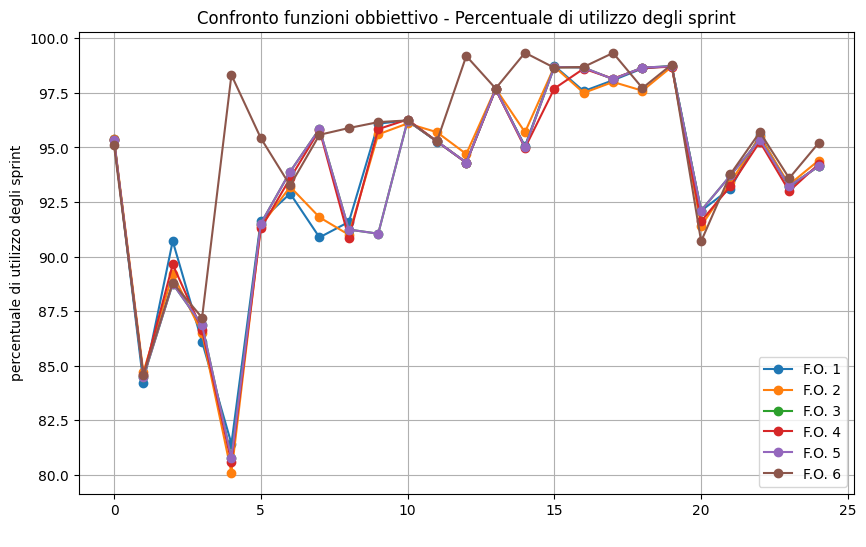

In [67]:
arrays = [coll11, coll12, coll13, coll14, coll15, coll16]

plt.figure(figsize=(10,6))

for i, arr in enumerate(arrays):
    plt.plot(arr, marker='o', label=f'F.O. {i+1}')  # aggiunta legenda

plt.xlabel(" ")  # X senza indicazione
plt.ylabel("percentuale di utilizzo degli sprint")
plt.title("Confronto funzioni obbiettivo - Percentuale di utilizzo degli sprint")
plt.grid(True)
plt.legend()  # mostra la legenda
plt.show()